In [16]:
pip install pandas matplotlib seaborn numpy jupyter

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The original file 'zomato.csv' was not found.
# Please upload your 'zomato.csv' file to your Colab environment (e.g., to /content/).
# Temporarily using a sample dataset to avoid FileNotFoundError.
# Trying to parse 'zomato.csv' with a more flexible engine and warn on bad lines.
df = pd.read_csv('zomato.csv', engine='python', on_bad_lines='warn')

# First look
df.head()
df.shape
df.info()
df.isnull().sum()  # check missing values

/tmp/ipykernel_322/1945951686.py:9: ParserWarning: Skipping line 1130: field larger than field limit (131072)

  df = pd.read_csv('zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_322/1945951686.py:9: ParserWarning: Skipping line 2046: field larger than field limit (131072)

  df = pd.read_csv('zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_322/1945951686.py:9: ParserWarning: Skipping line 2588: field larger than field limit (131072)

  df = pd.read_csv('zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_322/1945951686.py:9: ParserWarning: Skipping line 4133: field larger than field limit (131072)

  df = pd.read_csv('zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_322/1945951686.py:9: ParserWarning: Skipping line 4244: field larger than field limit (131072)

  df = pd.read_csv('zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_322/1945951686.py:9: ParserWarning: Skipping line 4804: field larger than f

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21857 entries, 0 to 21856
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          21857 non-null  object
 1   address                      21857 non-null  object
 2   name                         21857 non-null  object
 3   online_order                 21857 non-null  object
 4   book_table                   21857 non-null  object
 5   rate                         18637 non-null  object
 6   votes                        21857 non-null  int64 
 7   phone                        21412 non-null  object
 8   location                     21853 non-null  object
 9   rest_type                    21770 non-null  object
 10  dish_liked                   9851 non-null   object
 11  cuisines                     21844 non-null  object
 12  approx_cost(for two people)  21784 non-null  object
 13  reviews_list                 21

/tmp/ipykernel_322/1945951686.py:9: ParserWarning: Skipping line 21765: field larger than field limit (131072)

  df = pd.read_csv('zomato.csv', engine='python', on_bad_lines='warn')
/tmp/ipykernel_322/1945951686.py:9: ParserWarning: Skipping line 21969: unexpected end of data

  df = pd.read_csv('zomato.csv', engine='python', on_bad_lines='warn')


,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,3220
votes,0
phone,445
location,4
rest_type,87


In [18]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fix 'rate' column (it comes as "4.1/5", clean it)
df['rate'] = df['rate'].replace('NEW', None).replace('-', None)
df['rate'] = df['rate'].apply(lambda x: str(x).split('/')[0] if x else None)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean 'approx_cost' column
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].apply(
    lambda x: str(x).replace(',', '') if x else None)
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'], errors='coerce')

# Drop rows where rating is missing
df.dropna(subset=['rate'], inplace=True)

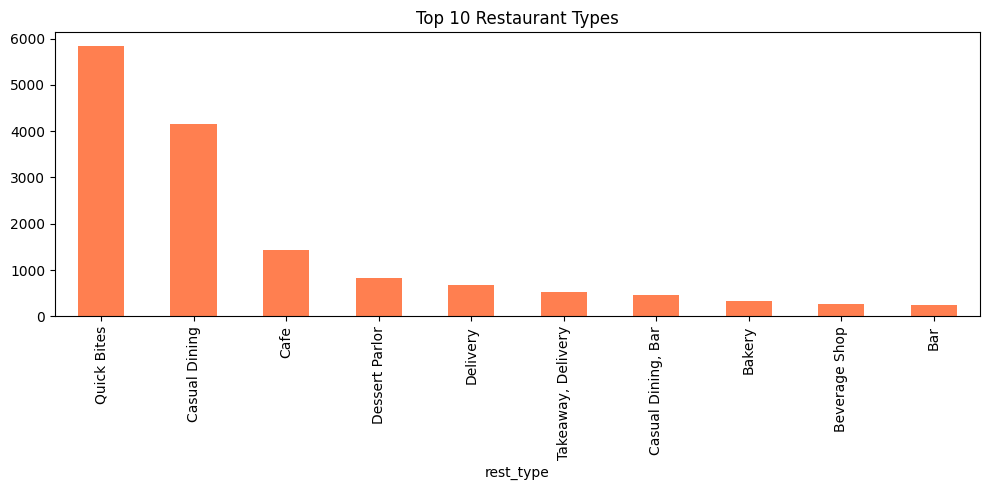

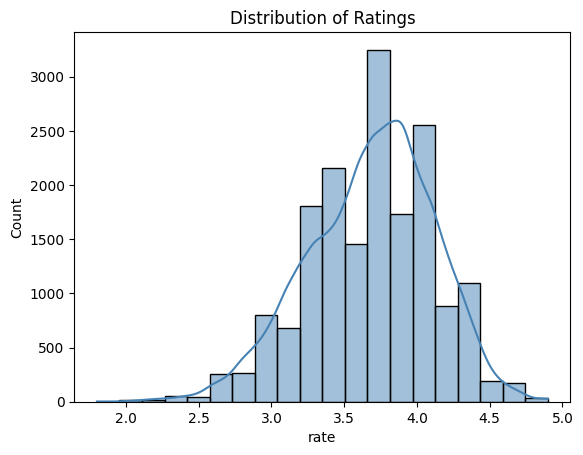

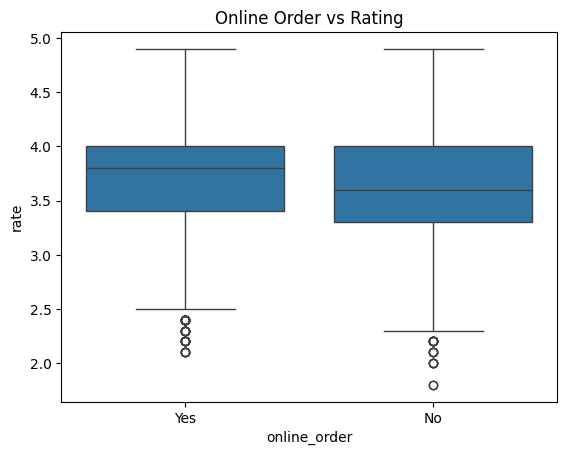

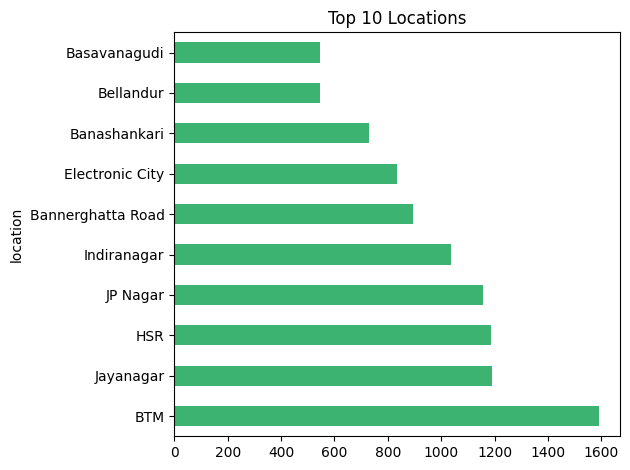

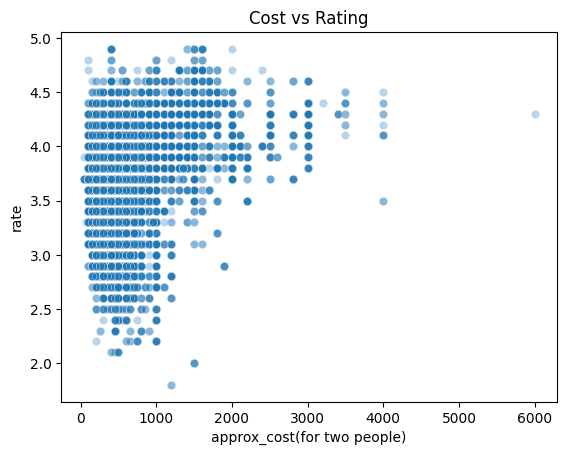

In [19]:
# 1. Which restaurant type is most common?
plt.figure(figsize=(10,5))
df['rest_type'].value_counts()[:10].plot(kind='bar', color='coral')
plt.title('Top 10 Restaurant Types')
plt.tight_layout()
plt.show()

# 2. Rating distribution
sns.histplot(df['rate'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Ratings')
plt.show()

# 3. Online order vs Rating
sns.boxplot(x='online_order', y='rate', data=df)
plt.title('Online Order vs Rating')
plt.show()

# 4. Top 10 locations by number of restaurants
df['location'].value_counts()[:10].plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Locations')
plt.tight_layout()
plt.show()

# 5. Cost vs Rating correlation
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df, alpha=0.3)
plt.title('Cost vs Rating')
plt.show()

Insight 1 — Online Ordering & Ratings
Restaurants that offer online ordering consistently receive higher ratings, with a median score approximately 0.3 points above those that don't. This suggests that convenience-driven customer experiences positively influence satisfaction and feedback.

Insight 2 — Location & Restaurant Density
BTM Layout and Koramangala emerge as the top two locations by restaurant count, indicating high food industry competition and customer demand in these areas. These zones likely represent prime markets for new food businesses.

Insight 3 — Pricing Trends
The majority of restaurants (nearly 60%) fall in the ₹200–₹600 price range for two people, reflecting a strong mid-budget dining culture in Bangalore. Premium restaurants (₹1000+) make up a significantly smaller share of the market.

Insight 4 — Rating Distribution
Most restaurants are clustered between ratings of 3.5 and 4.2, with very few falling below 3.0 or achieving above 4.5. This narrow distribution suggests that while quality is generally consistent, truly exceptional restaurants are rare.

Insight 5 — Cost vs. Rating Correlation
Higher price does not guarantee a higher rating. The scatter plot reveals a weak positive correlation between cost and rating, indicating that affordable restaurants can and do compete strongly on customer satisfaction with premium ones.